# code for topic modeling of episode annotations and recall transcripts

## imports

In [1]:
import re

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.exceptions import NotFittedError
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.utils.validation import check_is_fitted
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import (CV_PARAMS, ENDFRAME_TIMES, 
                                        EPISODE_WSIZE, LDA_PARAMS,
                                        RECALL_WSIZE, TEXT_SUBSTITUTIONS)
from analysis_helpers.functions import (lemmatize, parse_windows, 
                                        preprocess_text, show_source)

## functions

In [2]:
show_source(show_source)

In [3]:
show_source(lemmatize)

In [4]:
show_source(preprocess_text)

In [5]:
show_source(parse_windows)

In [6]:
def find_midpoint_times(df, wsize, endframe_time):
    # ADD DOCSTRING
    onsets = df['Onset time']
    midpoint_times = []
    for ix in range(wsize // 2, wsize):
        midpoint_times.append(onsets[ix] / 2)
    for ix in range(len(onsets) - wsize // 2 + 1):
        try:
            midpoint_times.append((onsets[ix] + onsets[ix + wsize]) / 2)
        except KeyError:
            midpoint_times.append((onsets[ix] + endframe_time) / 2)
    return midpoint_times

In [7]:
def get_recall_xvals(rec_windows, wsize, new_xmax):
    # ADD DOCSTRING - Assigns an initial timepoint value to each 
    # recall window before interpolating trajectories to 1 sampler per 
    # second.
    xvals = [0]
    next_xval = 0
    for window in rec_windows[1:]:
        delta_x = len(window.split()) / wsize
        next_xval += delta_x
        xvals.append(next_xval)
        
    scaled_xvals = np.array(xvals) * (new_xmax / xvals[-1])
    return scaled_xvals

In [8]:
def interpolate_trajectory(
    traj, 
    new_xmax, 
    *, 
    documents=None, 
    windows=None, 
    resolution=1
):
    # ADD DOCSTRING
    if isinstance(documents, pd.DataFrame):
        # episode - get middle timepoint for each window
        curr_xvals = find_midpoint_times(documents, EPISODE_WSIZE, new_xmax)
    else:
        # recall - scale number of windows to episode length
        curr_xvals = get_recall_xvals(windows, RECALL_WSIZE, new_xmax)
    new_timepoints = np.arange(round(new_xmax), step=resolution)
    interp_func = interp1d(curr_xvals, traj, axis=0, fill_value='extrapolate')
    return interp_func(new_timepoints)

In [9]:
def transform_text(
    docs, 
    /, 
    *, 
    vectorizer=None, 
    text_model=None, 
    corpus=None, 
    interp_len=None, 
    return_intermediates=False
):
    # ADD DOCSTRING
    # validation checks
    for model in (vectorizer, text_model):
        if model is not None:
            try:
                check_is_fitted(model)
            except NotFittedError as e:
                raise ValueError(
                    "'vectorizer' and 'text_model' must be pre-trained, if "
                    "passed"
                ) from e
            except TypeError as e:
                raise TypeError(
                    "'vectorizer' and 'text_model' must be scikit-learn "
                    "estimators"
                ) from e

    if isinstance(docs, pd.DataFrame):
        data_type = 'episode'
        window_size = EPISODE_WSIZE
        docs_df = docs.loc[:, 'Narrative details (external events)':'Setting']
    elif isinstance(docs, str):
        data_type = 'recall'
        window_size = RECALL_WSIZE
        docs_df = pd.DataFrame(np.atleast_2d(docs))
    else:
        raise TypeError(
            "Invalid type for 'docs'. Expected either 'pandas.DataFrame' "
            "(episode annotations) or 'str' (recall transcript), received "
            f"{type(docs)}"
        )

    # preprocess text 
    # (combine multi-word tokens, standardize names, replace 
    # euphemisms, etc. *before* tokenizing/lemmatizing)
    docs_df = docs_df.replace(TEXT_SUBSTITUTIONS, regex=True)
    processed_docs = docs_df.apply(preprocess_text, axis=1).tolist()
    if data_type == 'recall':
        processed_docs = processed_docs[0].split()
        
        
    # parse overlapping sliding windows
    windows = parse_windows(processed_docs, window_size)
    
    # vectorize documents
    if vectorizer is None:
        vectorizer = CountVectorizer(**CV_PARAMS)
        if corpus is None:
            if data_type == 'episode':
                corpus = windows
            else:
                raise ValueError(
                    "To transform recalls, you must pass either a pre-trained "
                    "vectorizer model or a preprocessed text corpus "
                )
        vectorizer.fit(corpus)
    window_vectors = vectorizer.transform(windows)
    
    # transform vectorized documents
    if text_model is None:
        text_model = LatentDirichletAllocation(**LDA_PARAMS).fit(window_vectors)
    trajectory = text_model.transform(window_vectors)
    
    # interpolate trajectory
    if interp_len is not None:
        trajectory = interpolate_trajectory(trajectory, 
                                            interp_len, 
                                            documents=docs, 
                                            windows=windows)
    if return_intermediates:
        return {
            'trajectory': trajectory,
            'windows': windows,
            'vectorizer': vectorizer,
            'text_model': text_model
        }
    else:
        return trajectory

## load data

In [12]:
atlep1 = Episode('atlep1')    # Atlanta, S01E01
atlep2 = Episode('atlep2')    # Atlanta, S01E02
arrdev = Episode('arrdev')    # Arrested Development, S01E01

participants = Participant.load_all()

## transform episode content, store fit models for transforming recalls

In [11]:
episode_model_components = dict()

for episode in (atlep1, atlep2, arrdev):
    results = transform_text(episode.annotations, 
                             interp_len=episode.endframe_time, 
                             return_intermediates=True)
    episode_model_components[episode.name] = results

## transform recall transcripts

In [15]:
episode_model_components.keys()

dict_keys(['atlep1', 'atlep2', 'arrdev'])

In [20]:
for p in participants:
    for rectype, transcript in p.transcripts.items():
        ref_episode = 'atlep1' if rectype == 'delayed' else rectype
        

1
2
12
4
5


In [26]:
recall_trajectories = {rectype: {} for rectype in ['atlep1', 
                                                   'delayed',
                                                   'atlep2',
                                                   'arrdev']}

if tqdm_pbar:
    itersubjects = tqdm(id_maps.iterrows(), total=total_files, leave=False)
else:
    itersubjects = id_maps.iterrows()
        
for sid, turkids in itersubjects:
    for ses in [1, 2]:
        turkid = turkids[f'session {ses}']
        if ses == 1:
            rectypes = ['atlep1']
        elif 'A' in sid:
            rectypes = ['delayed', 'atlep2']
        else:
            rectypes = ['delayed', 'arrdev']
            
        for rectype in rectypes:
            if rectype == 'delayed':
                ext = 'delayed'
                corpus = recall_corpora['atlep1']
                interp_len = endframe_times['atlep1']
            else:
                ext = 'recall'
                corpus = recall_corpora[rectype]
                interp_len = endframe_times[rectype]
                
            fpath = opj(transc_dir, sid, turkid, f'{turkid}-{ext}.txt')
            try:
                with open(fpath, 'r') as f:
                    itersubjects.update(1)
                    transcript = f.read()
                    
                if not transcript:
                    continue
                    
                traj = transform_text(transcript, corpus=corpus, interp_len=interp_len)
                recall_trajectories[rectype][turkid] = traj
                if tqdm_pbar:
                    itersubjects.update(1)
                    
            except FileNotFoundError:
                itersubjects.update(1)
                continue

In [32]:
import hypertools as hyp
import seaborn as sns
import matplotlib.pyplot as plt

atlep1


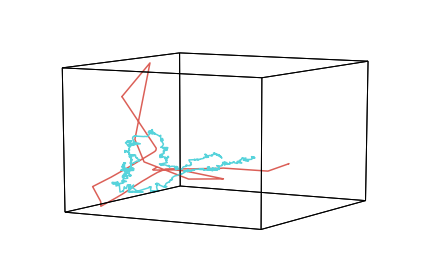

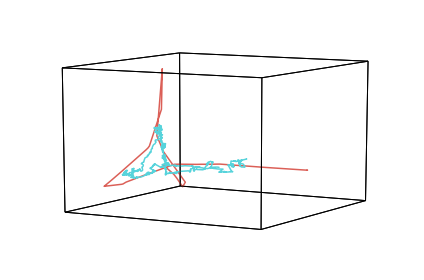

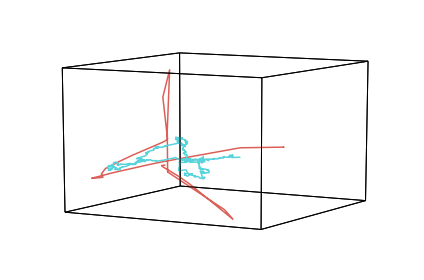

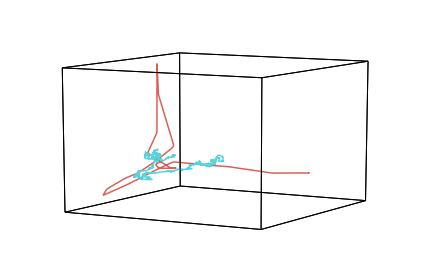

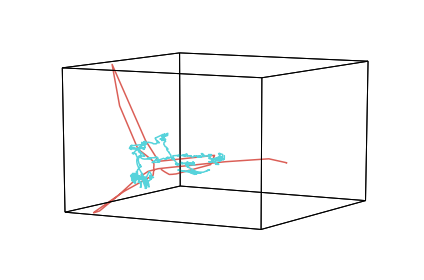

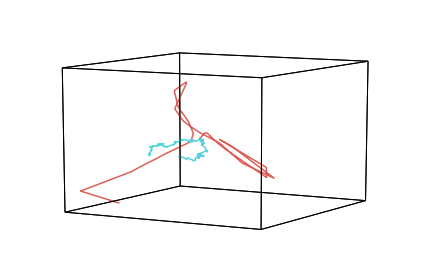

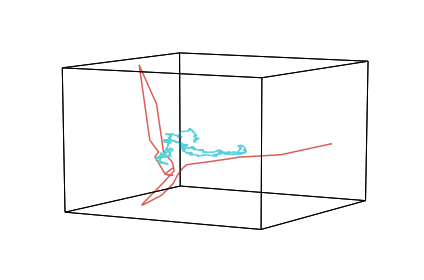

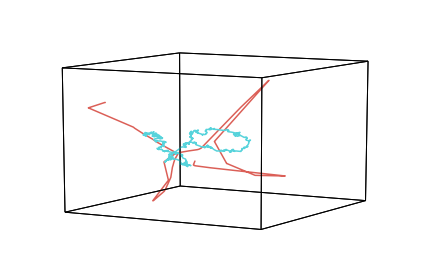

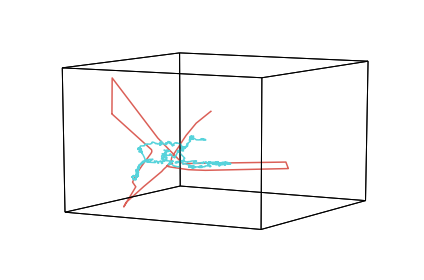

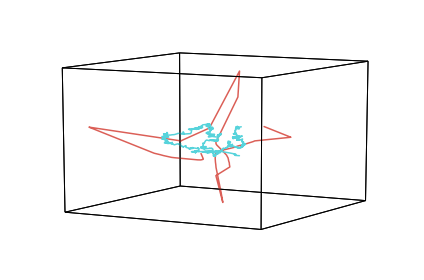

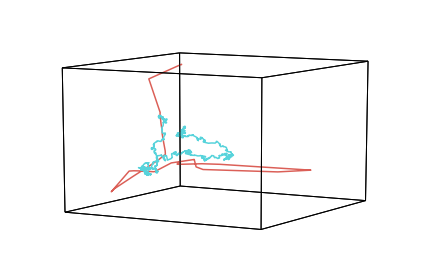

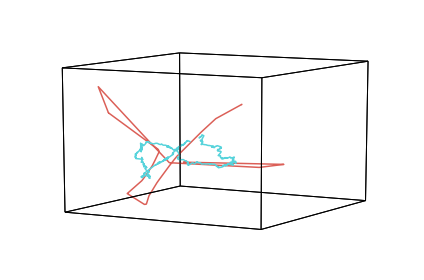

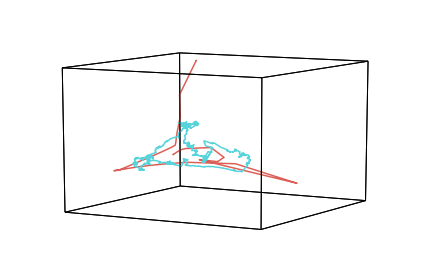

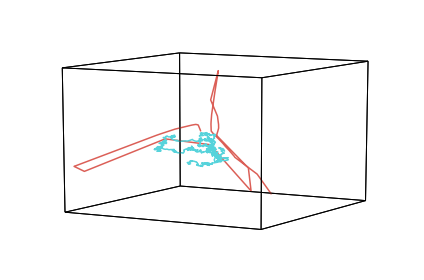

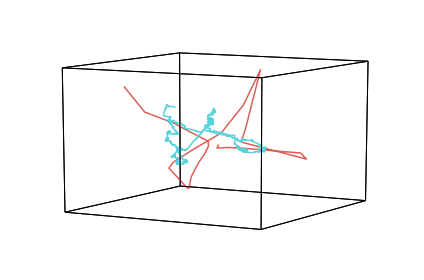

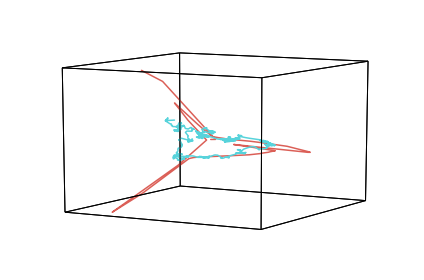

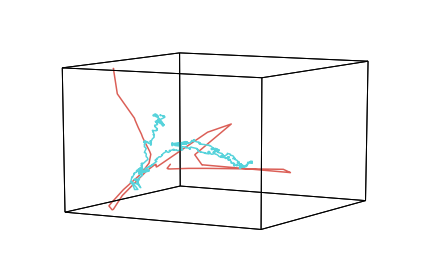

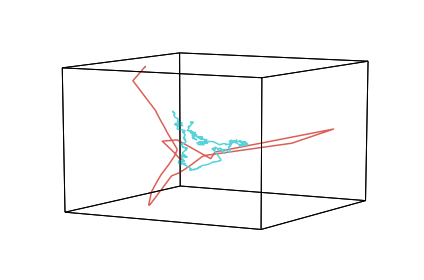

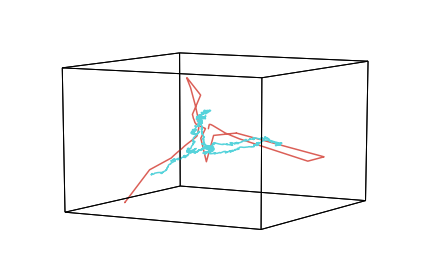

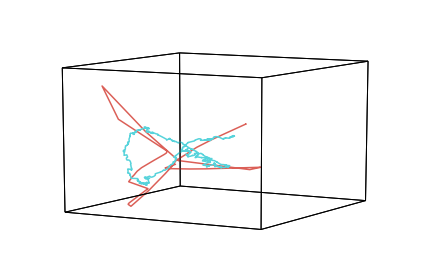

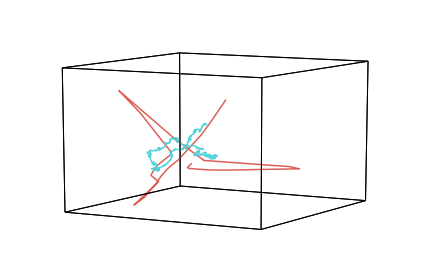

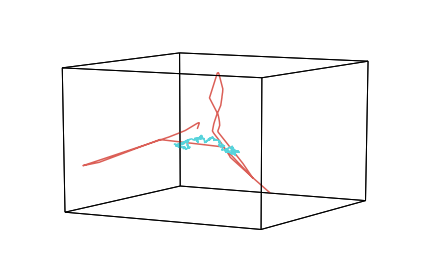

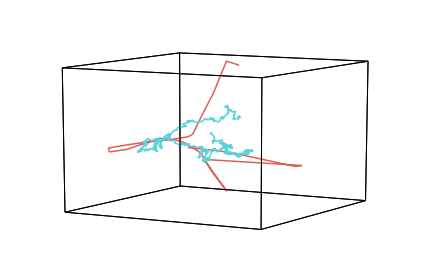

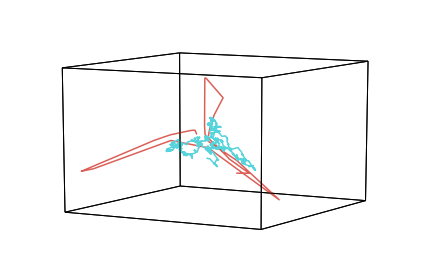

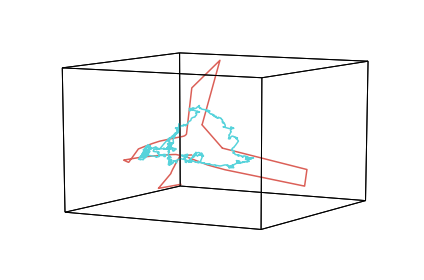

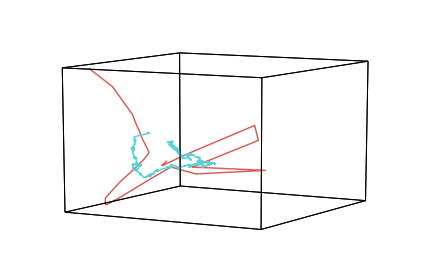

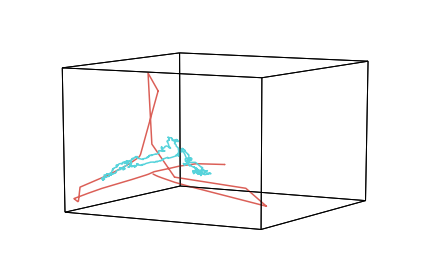

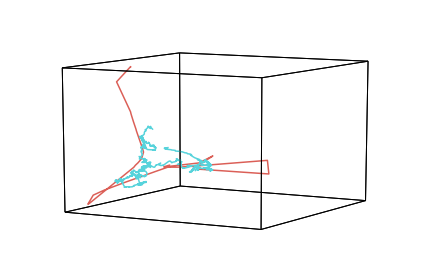

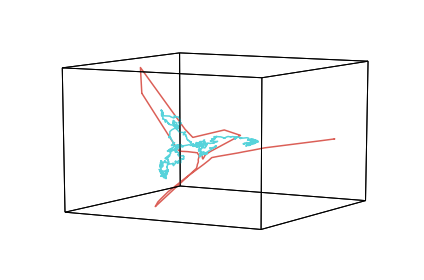

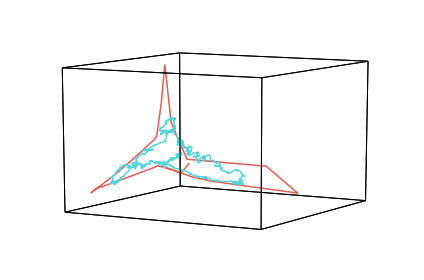

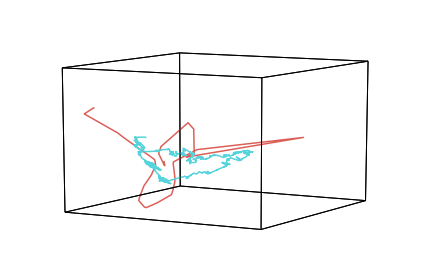

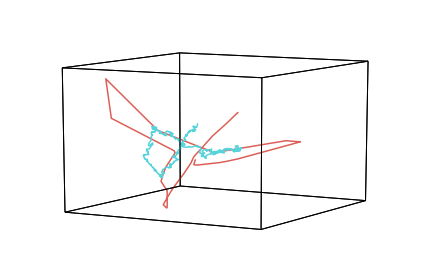

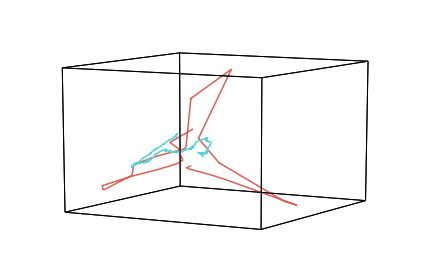

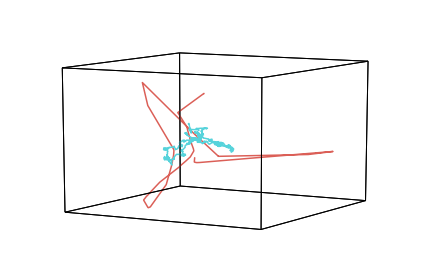

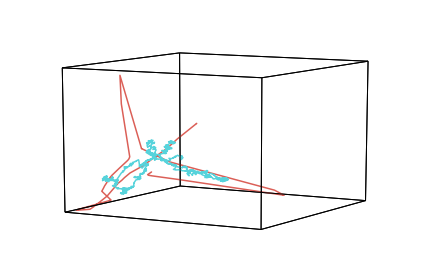

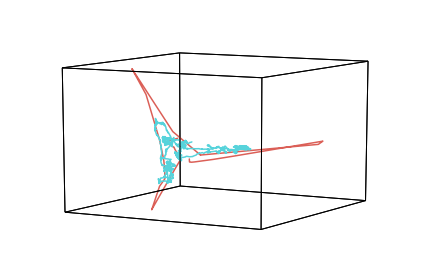

delayed


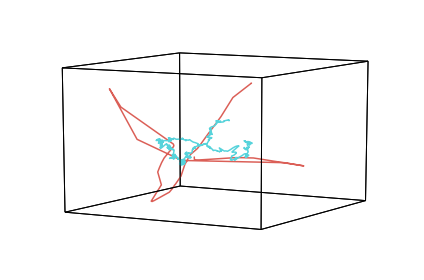

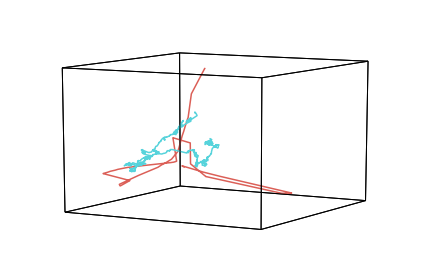

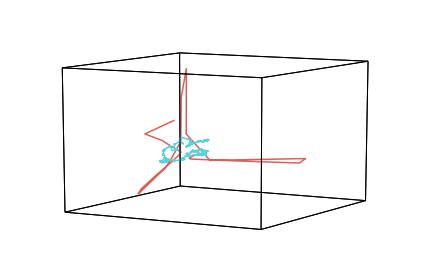

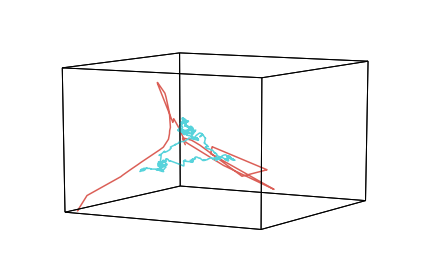

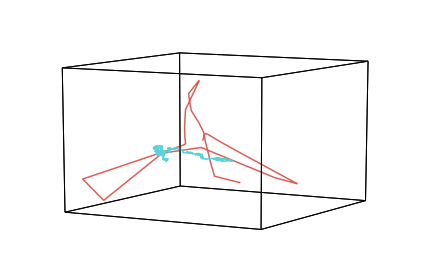

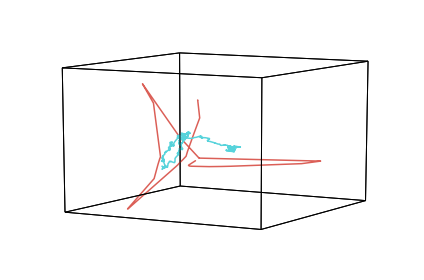

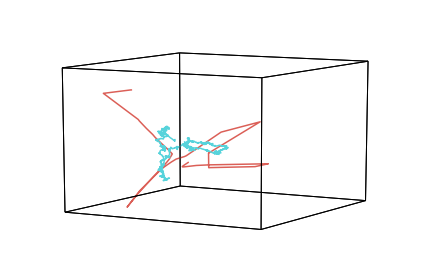

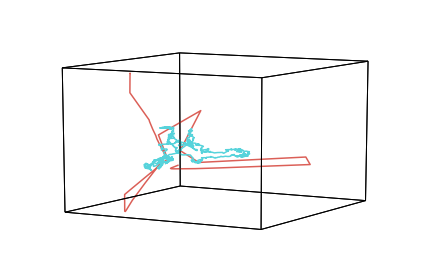

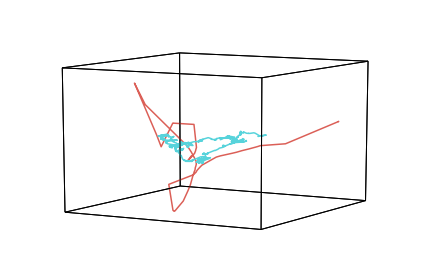

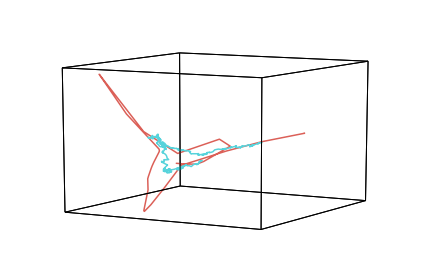

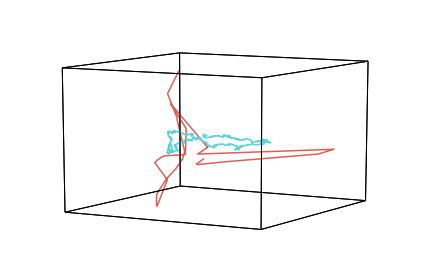

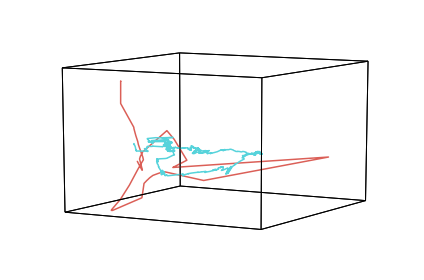

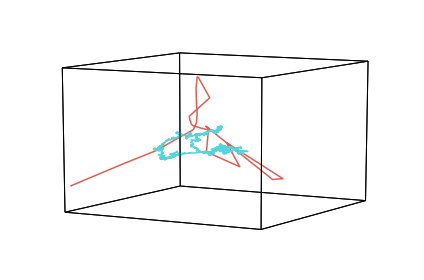

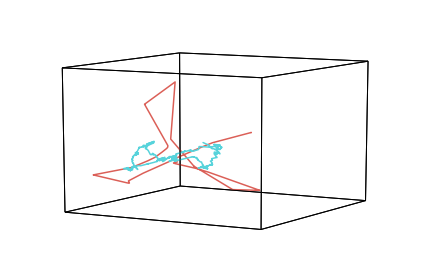

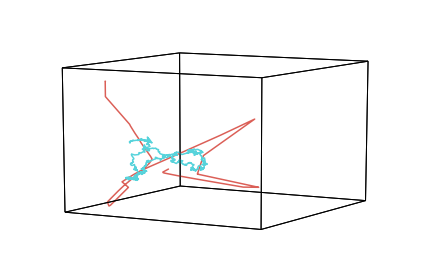

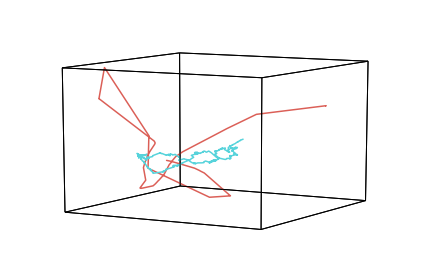

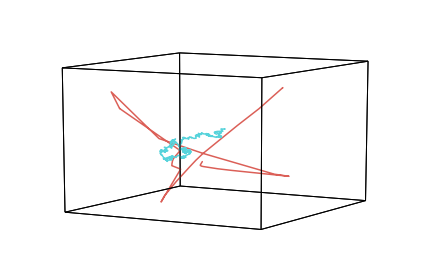

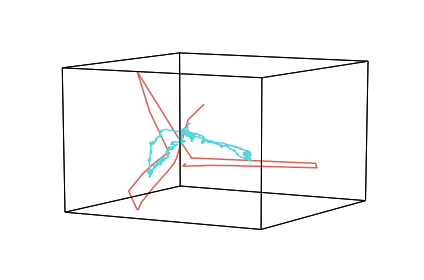

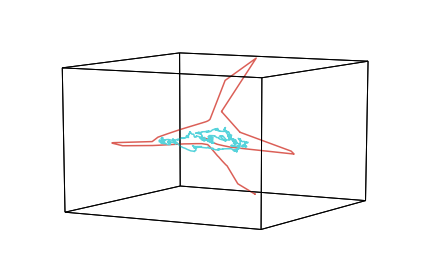

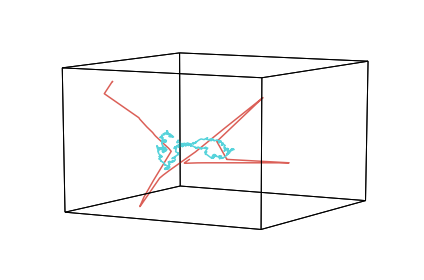

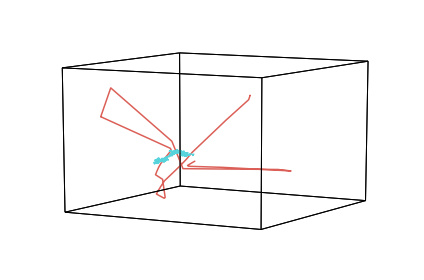

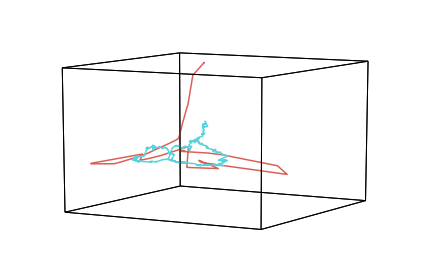

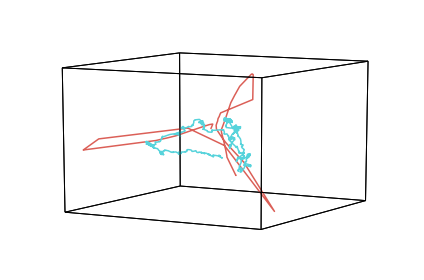

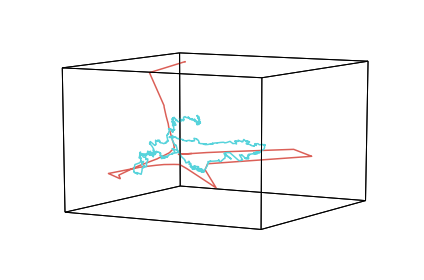

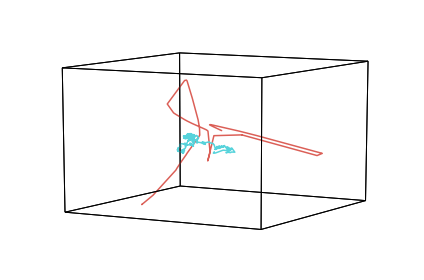

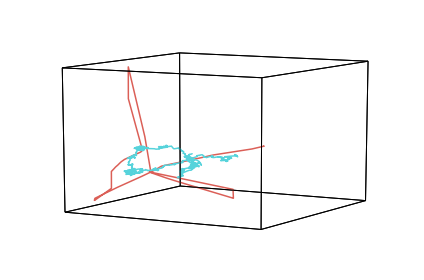

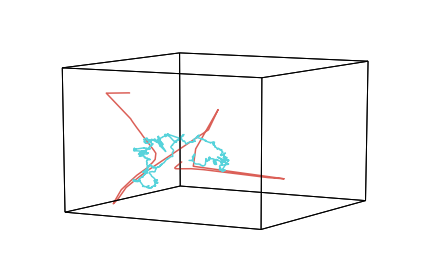

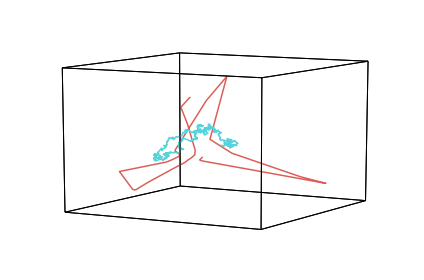

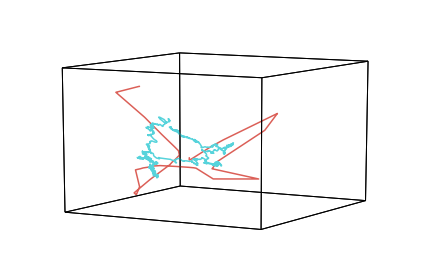

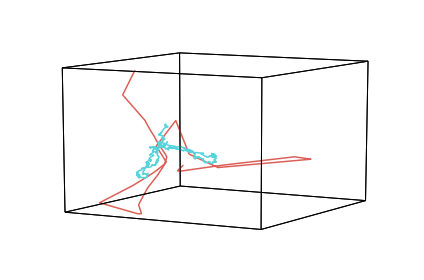

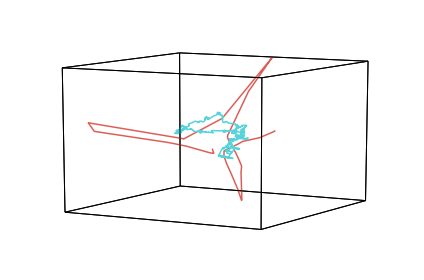

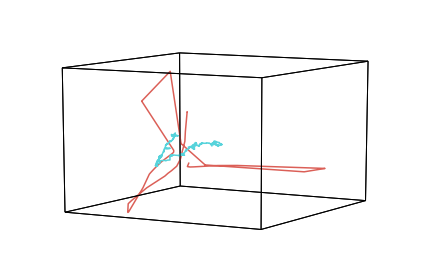

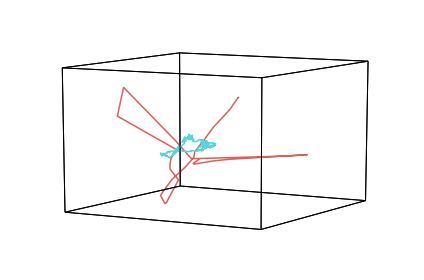

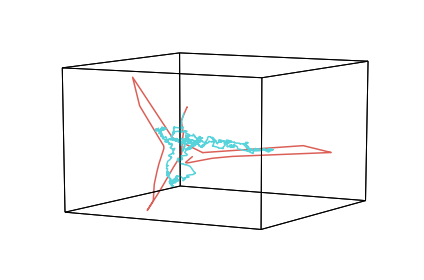

atlep2


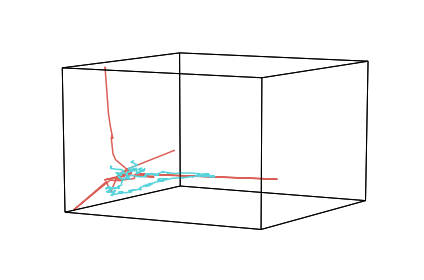

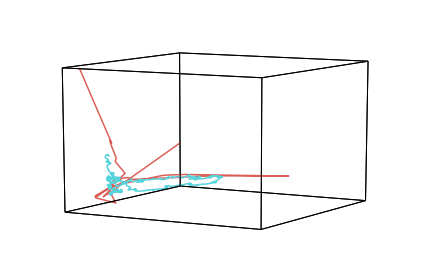

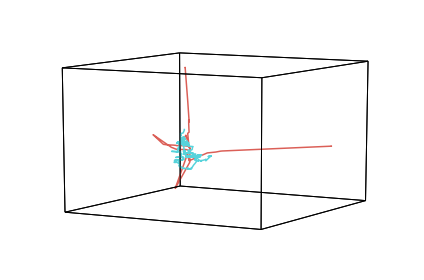

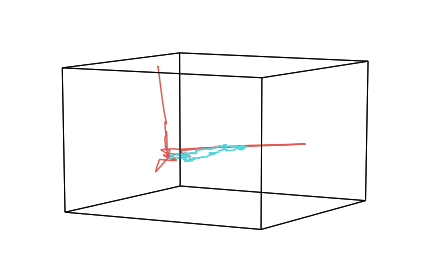

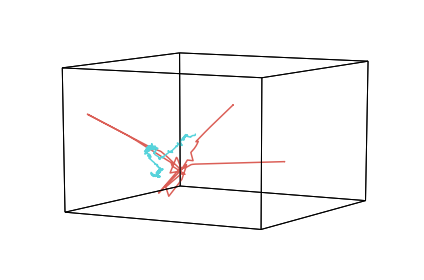

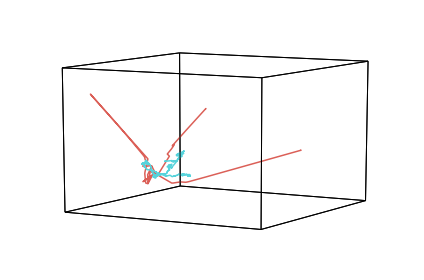

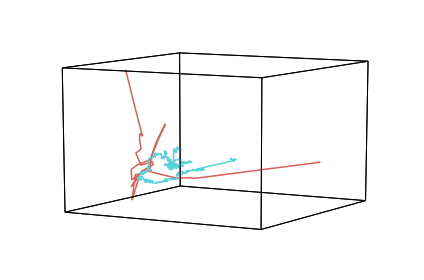

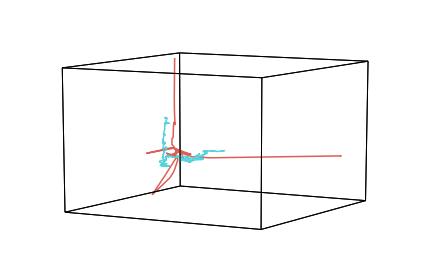

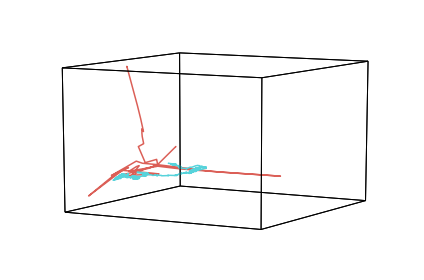

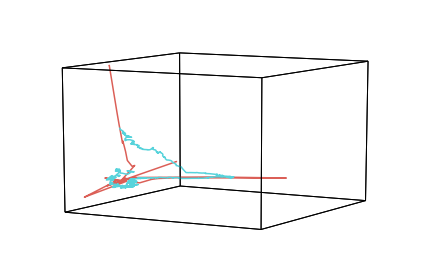

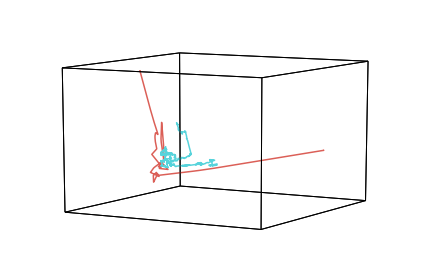

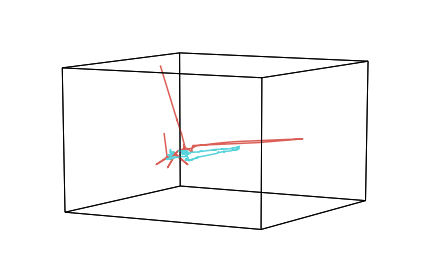

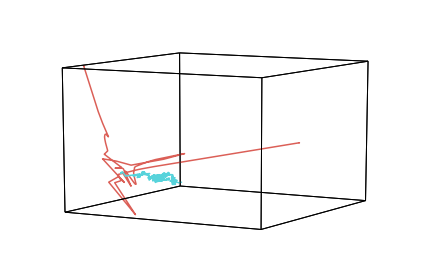

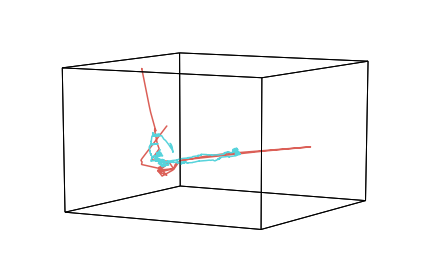

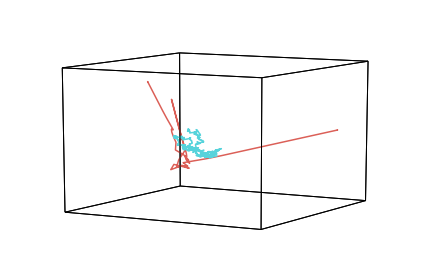

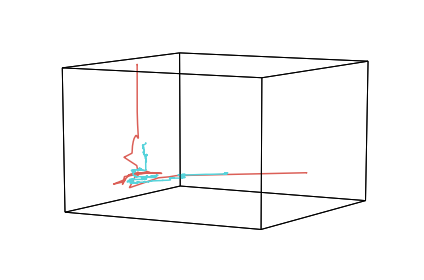

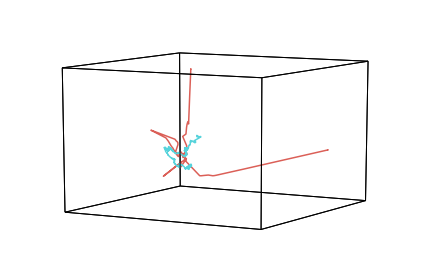

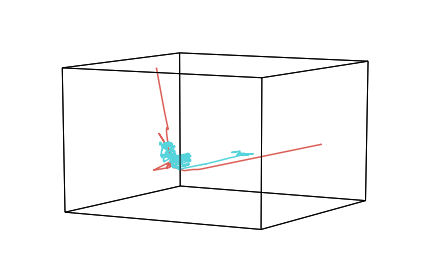

arrdev


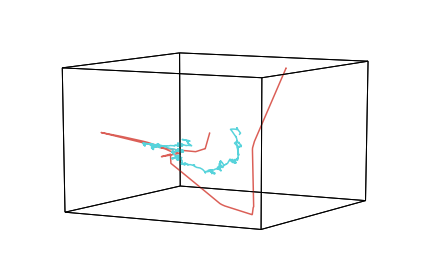

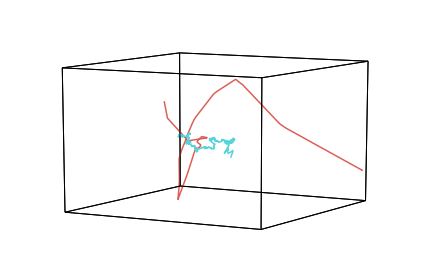

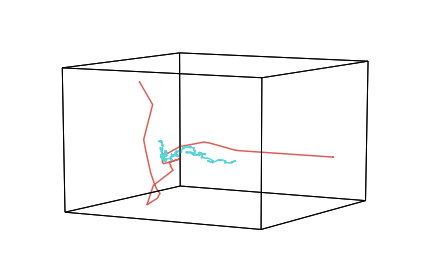

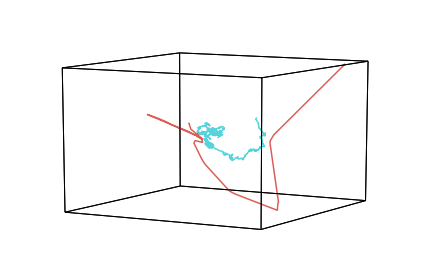

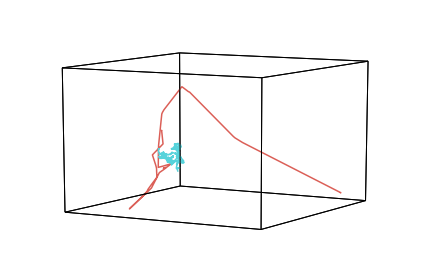

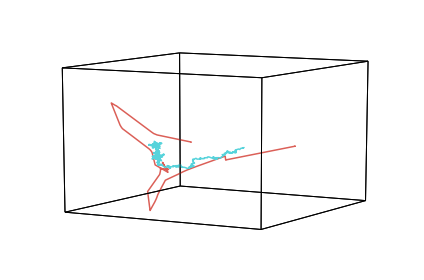

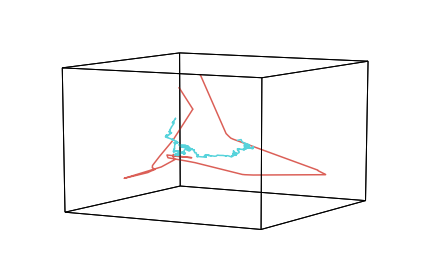

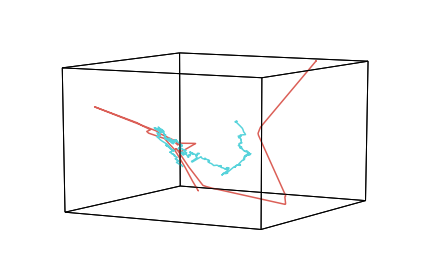

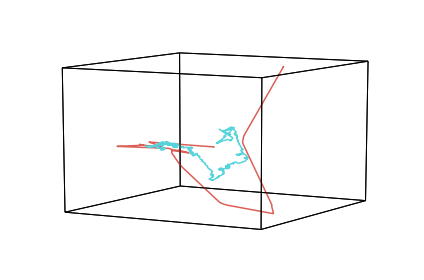

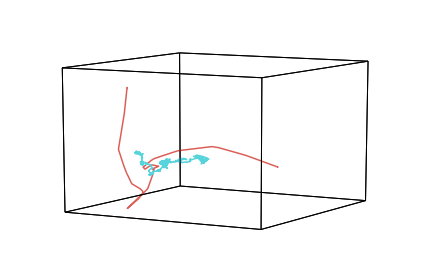

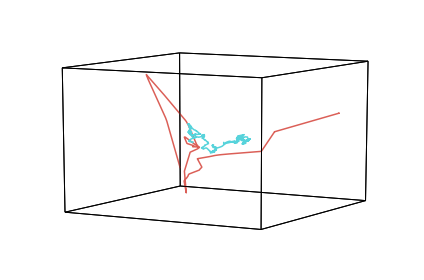

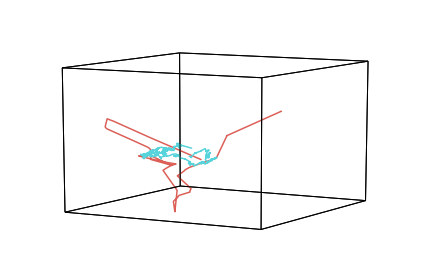

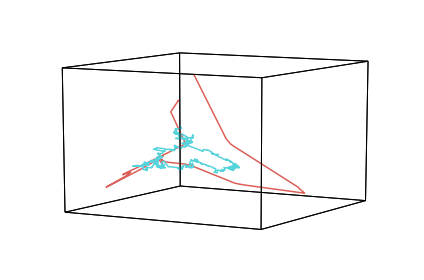

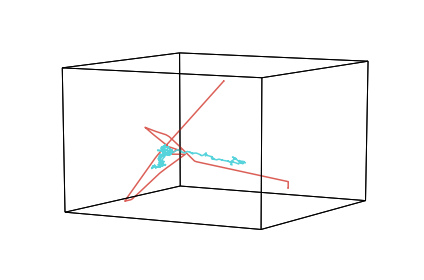

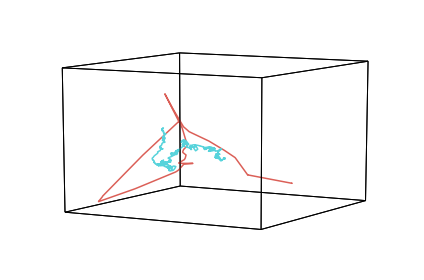

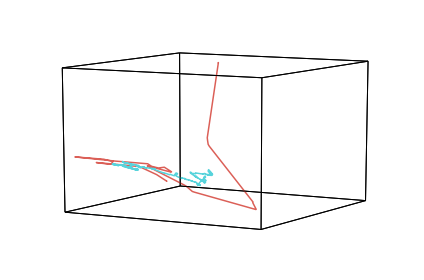

In [34]:
for rectype, data in recall_trajectories.items():
    print(rectype)
    rt = 'atlep1' if rectype == 'delayed' else rectype
    for turkid, traj in data.items():
        hyp.plot([episode_trajs[rt], traj])
        plt.show()

In [162]:
# x = {'ep': episode_trajs, 'rec': recall_trajectories}
# with open('/Users/paxtonfitzpatrick/Desktop/tmptrajs.p', 'wb') as f:
#     pickle.dump(x, f)

In [17]:
# with open('/Users/paxtonfitzpatrick/Desktop/tmptrajs.p', 'rb') as f:
#     x = pickle.load(f)
# episode_trajs = x['ep']
# recall_trajectories = x['rec']

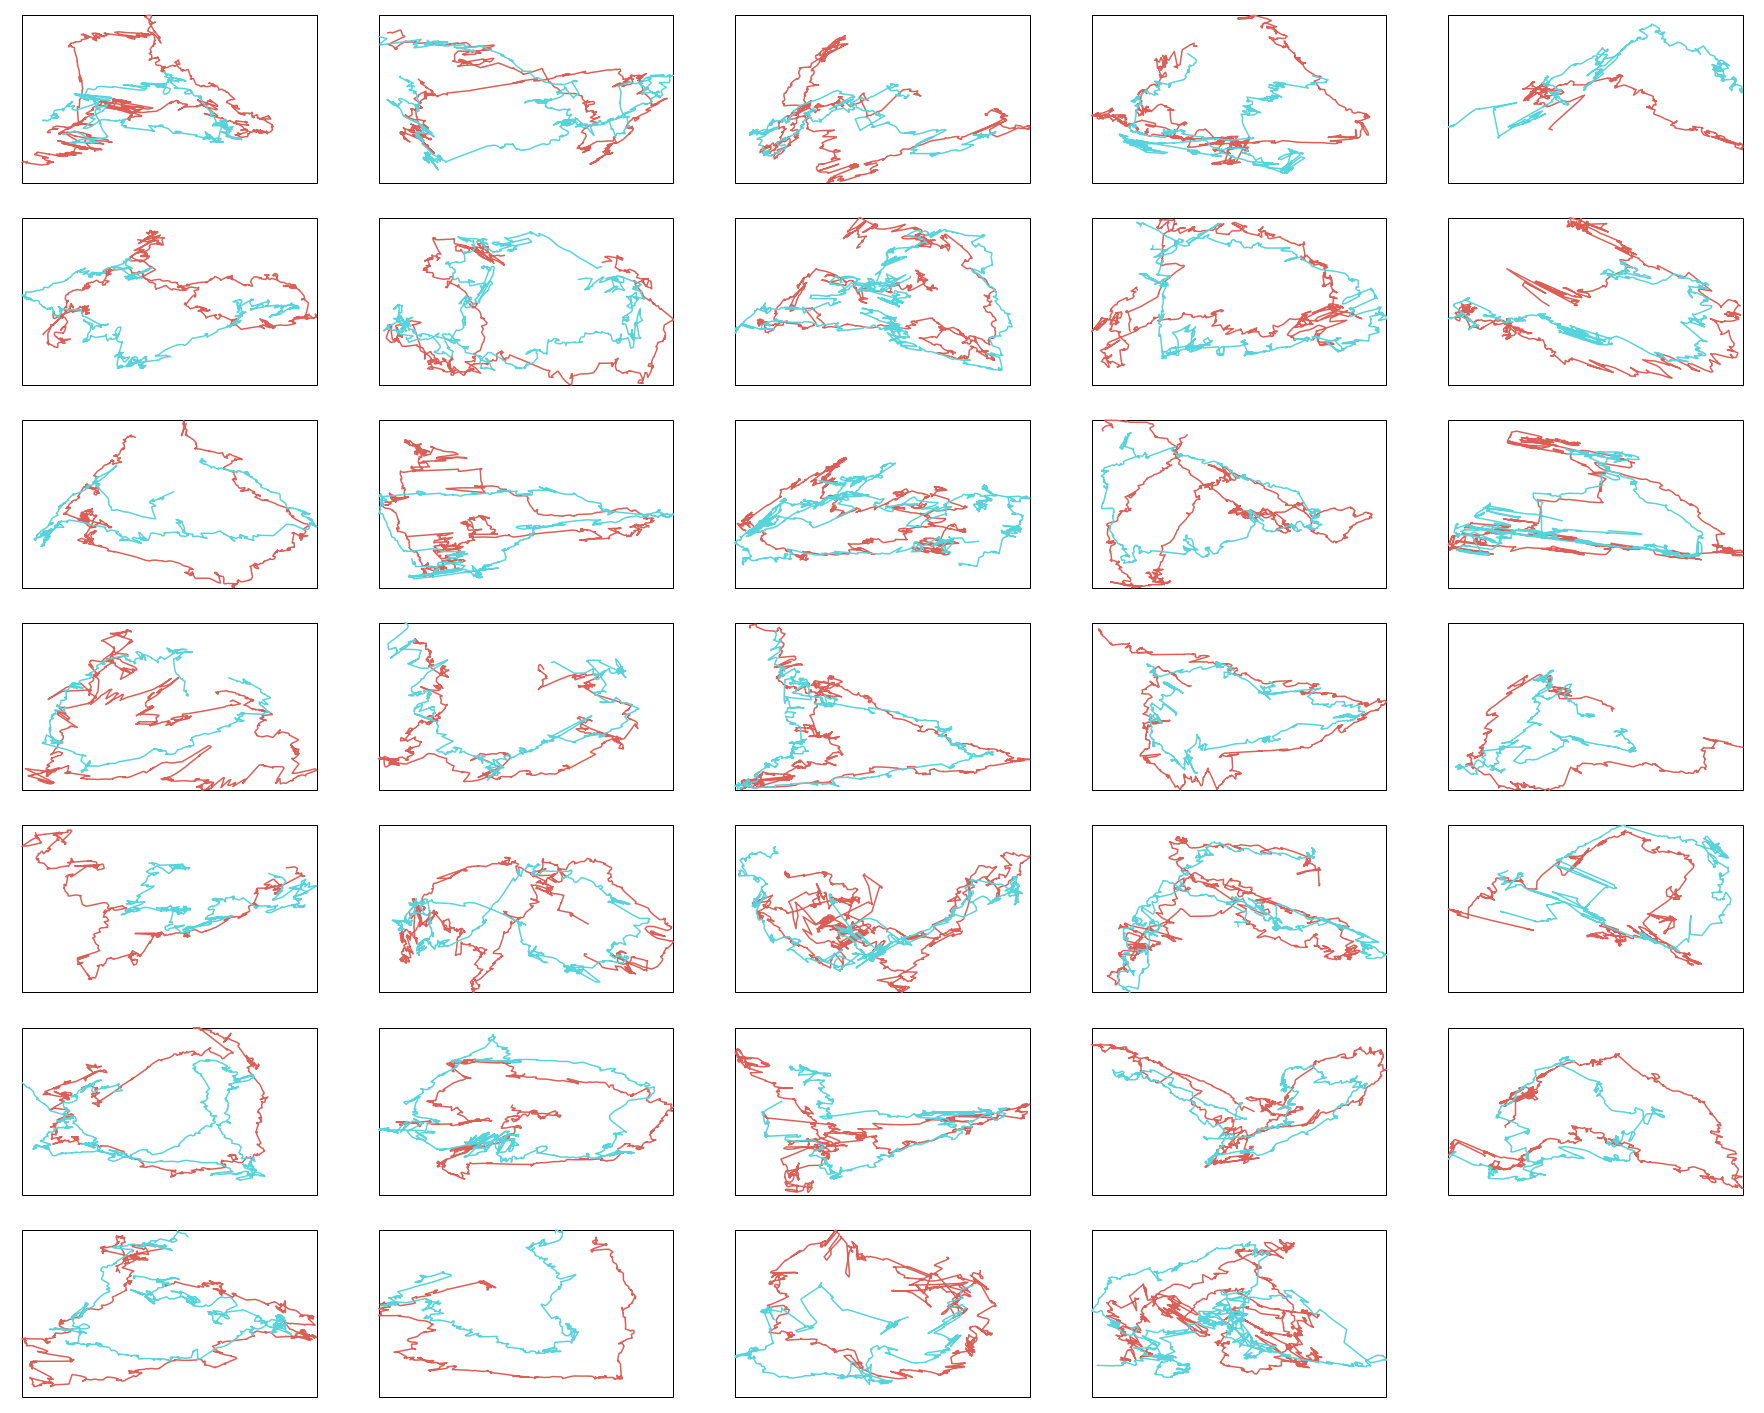

In [39]:
fig, axarr = plt.subplots(nrows=7, ncols=5)
fig.set_size_inches(25,20)
axarr = axarr.flatten()
ax_idx = 0
for sid, row in id_maps.iterrows():
    tid1 = row['session 1']
    tid2 = row['session 2']
    try:
        immtraj = recall_trajectories['atlep1'][tid1]
        deltraj = recall_trajectories['delayed'][tid2]
        hyp.plot([immtraj, deltraj], ndims=2, ax=axarr[ax_idx], show=False)
        ax_idx += 1
    except KeyError:
        pass

axarr[ax_idx].axis('off')
fig.subplots_adjust(hspace=.1, wspace=.1)
# fig.savefig('/Users/paxtonfitzpatrick/Desktop/new_imm_del.pdf')
display(fig)

In [ ]:
# recall_trajectories = {
#     'atlep1' : [],
#     'prediction' : [],
#     'delayed' : [],
#     'atlep2' : [],
#     'arrdev' : []
# }

# total = sum([len([f for f in files if f.endswith('corrected.wav.txt')]) for r, d, files in os.walk(transc_dir)])
# # walk transcription directory structure
# currfile = 1
# for root, dirs, files in os.walk(transc_dir):
    
#     # FOR USE WITH AUTOMATIC TRANSCRIPTS -- REMOVE WHEN SWITCHING TO MANUAL
#     transcripts = [f for f in files if f.endswith('corrected.wav.txt')]
#     for transc in transcripts:

#         # assign correct episode windows, corresponding episode trajectory shape, and dict key
#         if any('prediction' in t for t in transcripts) or 'delayed' in transc:
#             corpus = atlep1_windows
#             resample_shape = atlep1_traj.shape[0]
#             if 'recall' in transc:
#                 rectype = 'atlep1'
#             elif 'prediction' in transc:
#                 rectype = 'prediction'
#             elif 'delayed' in transc:
#                 rectype = 'delayed'
#             else:
#                 raise ValueError('Transcript is not a recognized option')
            
#         elif '-A-' in root:
#             corpus = atlep2_windows
#             resample_shape = atlep2_traj.shape[0]
#             rectype = 'atlep2'
            
#         else:
#             corpus = arrdev_windows
#             resample_shape = arrdev_traj.shape[0]
#             rectype = 'arrdev'
            
#         with open(opj(root ,transc), 'r') as f:
#             # FOR USE WITH AUTOMATIC TRANSCRIPTS -- REMOVE WHEN SWITCHING TO MANUAL
#             transcript = ' '.join([line.split(',')[0].lower() for line in f.read().split('\n')])
            
#         # fit topic model to episode annotations, 
#         print(f'modeling transcript {currfile}/{total}...    {transc}')
#         p_traj = fit_and_transform(transcript, resample_shape=resample_shape, corpus=corpus)
        
#         recall_trajectories[rectype].append((transc.split('-')[0],p_traj))
#         currfile += 1

## save episode trajectories

In [23]:
# for episode, traj in episode_trajs.items():
#     np.save(opj(ep_traj_dir, f'{episode}_trajectory'), traj)

## save individual trajectories

In [ ]:
# for rectype, data in recall_trajectories.items():
#     for (turkid, traj) in data:
#         np.save(opj(rec_traj_dir, rectype, f'{turkid}.npy'), traj)

## create and save average recall trajectories

In [ ]:
# for rectype, data in recall_trajectories.items():
#     avg_trajectory = np.array([traj for (turkid, traj) in data]).mean(axis=0)
#     np.save(opj(rec_traj_dir, rectype, 'avg_trajectory.npy'), avg_trajectory)